# 1.3.Apply degradations to images (patched) and writing to disk
This notebook:
1. Reads in reference patched images generated and written in 1.2.
2. Applies degrading image transformations from albumentations and cv2 to reference patches.
3. Writies results to disks, keeping track of files to reference image metadata.

In [1]:
from collections import Counter

import lance
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

from utils.validate_config import (
    load_yaml_config,
    require_config_directory,
    require_config_membership,
    require_config_value,
)
from utils.iter_data import iter_lance_fragments
from utils.encoding import decode_pixels
from utils.degrade_spec import build_degradation_specs, specs_to_frame
from utils.apply_degradation import build_degradation_stack
from utils.write_degrade_image import write_degraded_images

/home/weishanli/anaconda3/envs/vs-metric-analysis/lib/python3.12/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.1'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## Pathing

In [2]:
config = load_yaml_config("degradation_config.yaml")
analysis_dir = require_config_directory(config, "analysis_out_dir")

reference_patch_dir = analysis_dir / "patches" / "reference_records"
if not reference_patch_dir.exists():
    raise RuntimeError(
        f"Reference patch directory {reference_patch_dir} does not exist. "
        "Run notebook 1.2 first."
    )

reference_lance_dir = reference_patch_dir / "data.lance"
if not reference_lance_dir.exists():
    raise RuntimeError(
        f"Reference Lance directory {reference_lance_dir} does not exist. "
        "Run notebook 1.2 first."
    )

channels = require_config_value(config, "channels")
input_channel = require_config_membership(config, "input_channel", "channels")
target_channel_keys = [channel for channel in channels if channel != input_channel]

degrade_patch_output_dir = analysis_dir / "patches" / "degraded_records"
degrade_patch_output_dir.mkdir(parents=True, exist_ok=True)

## Tabulate channel count in reference images written

In [3]:
reference_dataset = lance.dataset(reference_lance_dir)
reference_fragments = list(reference_dataset.get_fragments())

channel_counts: Counter[str] = Counter()
sample_fragment_id: int | None = None

for fragment in reference_fragments:
    for batch in fragment.scanner(columns=["channel"]).to_batches():
        channel_values = batch["channel"].to_pylist()

        channel_counts.update(
            str(value)
            for value in channel_values
        )

        if sample_fragment_id is None and channel_values:
            sample_fragment_id = fragment.fragment_id

if sample_fragment_id is None:
    raise ValueError("No reference records found.")

reference_record_count = sum(channel_counts.values())

print(
    f"Found {reference_record_count:,} target reference records "
    f"across {len(reference_fragments):,} reference fragments."
)

reference_counts = pd.Series(
    channel_counts,
    name="reference_count",
)

reference_counts

Found 94,090 target reference records across 736 reference fragments.


OrigER      18818
OrigRNA     18818
OrigAGP     18818
OrigMito    18818
OrigDNA     18818
Name: reference_count, dtype: int64

## Degradation catalog

Each reference patch is degraded with the 6 types $\times$ 6 severity levels = 36 variants. 

For the sake of reducing number of file writes all variants sourcing from the same reference image ("sibling" variants) are saved as a single tiff stack. 
This stacking will also help reduce file reads during later metric evaluation when all "sibling" variants will be compared against the raw reference.

The 36 page catalog is defined here based on seed derived from the reference stem and base seed.

In [4]:
degradation_specs = build_degradation_specs()
degradation_catalog = specs_to_frame(degradation_specs)
degradation_catalog.head()
degradation_catalog.to_csv(analysis_dir / "degradation_catalog.csv", index=False)

## Preflight example degradation on small batch

target reference records            94090
degradation pages per record           36
logical degraded images           3387240
uncompressed MiB per stack            9.0
uncompressed total TiB           0.807581
records per Parquet row group         128
Parquet compression                  zstd


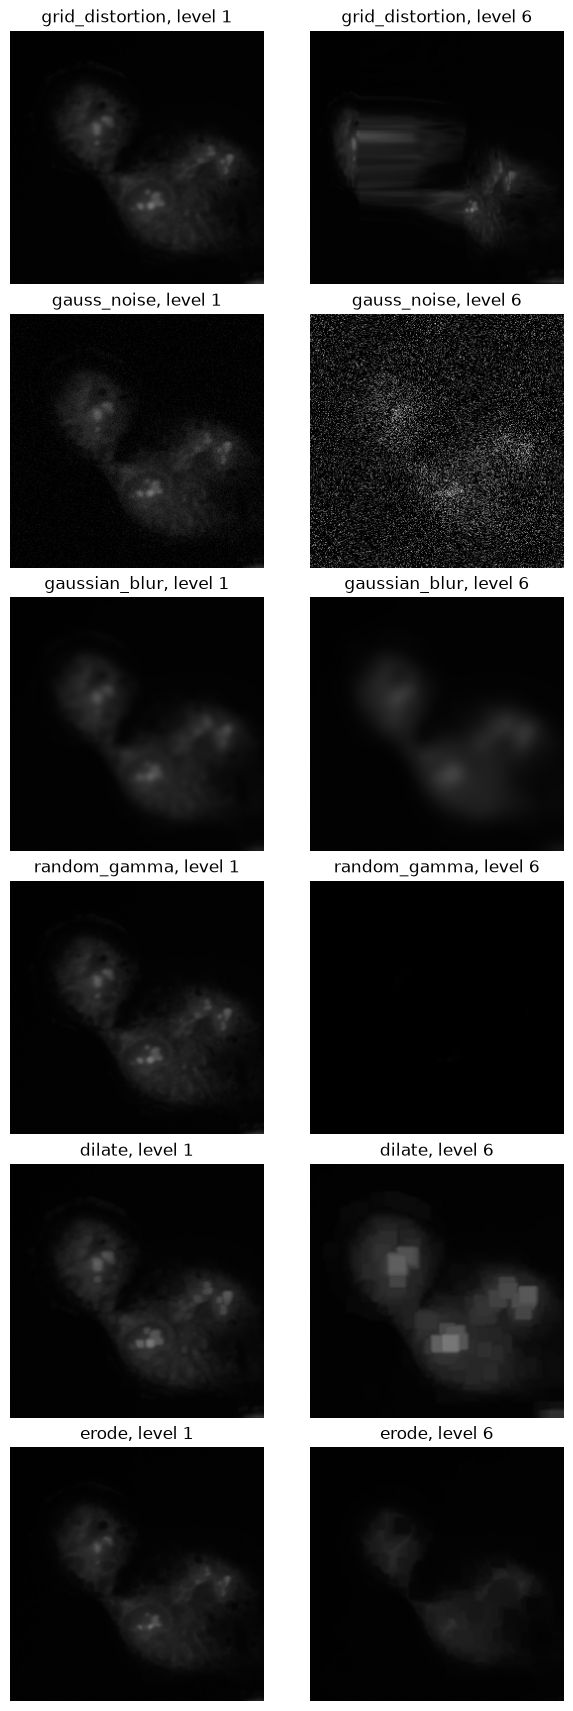

In [5]:
_, _, sample_table = next(iter_lance_fragments(reference_lance_dir))

sample_record = sample_table.to_pylist()[0]
sample_image = decode_pixels(
    sample_record["pixels"],
    sample_record["shape"],
    sample_record["dtype"],
    sample_record["byte_order"],
)
sample_stack = build_degradation_stack(
    sample_image,
    str(sample_record["record_id"]),
    degradation_specs,
    base_seed=42,
)

page_count = len(degradation_specs)
uncompressed_bytes_per_stack = sample_stack.nbytes
uncompressed_total_tib = (
    reference_record_count * uncompressed_bytes_per_stack / 1024**4
)

degrade_stack_summary = pd.Series(
    {
        "target reference records": reference_record_count,
        "degradation pages per record": page_count,
        "logical degraded images": reference_record_count * page_count,
        "uncompressed MiB per stack": uncompressed_bytes_per_stack / 1024**2,
        "uncompressed total TiB": uncompressed_total_tib,
        "records per Parquet row group": 128,
        "Parquet compression": "zstd",
    }
)
print(degrade_stack_summary.to_string())

figure, axes = plt.subplots(6, 2, figsize=(6, 17), constrained_layout=True)
transform_names = degradation_catalog["transform_name"].drop_duplicates()

for row_index, transform_name in enumerate(transform_names):
    family = degradation_catalog.loc[
        degradation_catalog["transform_name"] == transform_name
    ]
    page_indexes = [
        int(family.iloc[0]["page_index"]),
        int(family.iloc[-1]["page_index"]),
    ]

    for column_index, page_index in enumerate(page_indexes):
        axes[row_index, column_index].imshow(
            sample_stack[page_index],
            cmap="gray",
            vmin=0,
            vmax=0.5,
        )
        level = degradation_catalog.iloc[page_index]["transform_level"]
        axes[row_index, column_index].set_title(
            f"{transform_name}, level {level}"
        )
        axes[row_index, column_index].axis("off")

plt.show()

## Create and write degraded patches iterating over saved reference parquet sahrds. 

The writer stores one self-describing row per crop/channel under `reference_records/`. Each row contains a stable `record_id`, the normalized float32 `YX` pixel buffer, its shape and dtype contract, source-image provenance, crop geometry, and all image-level metadata. Bounded Parquet shards are written through validated temporary files and valid completed shards are reused on rerun. Reference and future degraded-stack datasets use the same record envelope and map through the same `record_id`.

In [6]:
write_degraded_images(
    reference_lance_dir=reference_lance_dir,
    specs=degradation_specs,
    output_dir=degrade_patch_output_dir,
    base_seed=42,
)

Writing degraded images from Lance reference


Writing degraded images:   0%|          | 0/736 [00:00<?, ?it/s]